In [1]:
gid_map = {
    'scalability': '1513474150',
    'optimality': '2117154112',
    'profiling_agg': '1122559114',
    'time_vs_optimality': '1755793917'
}

In [2]:
import gdown
import pandas as pd
import numpy as np
from scipy import stats

sheet_id = "1WUywPr_TxlUfPGVyMF0I2ALxXiHAyknKoZ3X13kKrUI"

def get_pandas_from_gid(gid_name):
    # Replace with your actual Google Sheet ID
    # Optionally: specify the sheet/tab number (gid=0 for the first sheet)
    gid = gid_map[gid_name]
    
    # Construct export URL
    url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}"
    
    # Set desired output filename
    output = f"{gid_name}.csv"
    
    # Download CSV using gdown
    gdown.download(url, output, quiet=False)
    original_df = pd.read_csv(output)
    return original_df

In [9]:
df = get_pandas_from_gid('time_vs_optimality')
df

/home/viniciusvdias/miniconda3/lib/python3.11/site-packages/gdown/parse_url.py:48: UserWarning: You specified a Google Drive link that is not the correct link to download a file. You might want to try `--fuzzy` option or the following url: https://drive.google.com/uc?id=None
  warnings.warn(
Downloading...
From: https://docs.google.com/spreadsheets/d/1WUywPr_TxlUfPGVyMF0I2ALxXiHAyknKoZ3X13kKrUI/export?format=csv&gid=1755793917
To: /home/viniciusvdias/repos/fractal-private/plots/time_vs_optimality.csv
15.6kB [00:00, 12.4MB/s]


,Graph Name,Objective Function,Initial Solutions,Timeout (ms),AVERAGE of Cost Best Solution,COUNT of Cost Best Solution,STDEV of Cost Best Solution,AVERAGE of Total Time (ms),AVERAGE of Time to Best Solution (ms),vns time to best solution (ms),vns total time (ms),vns best cost,baseline total time (ms),baseline best cost,total time delta (baseline - VNS) / baseline,total time delta (baseline - VNS-TTBS) / baseline,best cost delta (VNS - baseline) / baseline
0,amazon,densesubgraph,100,1000.0,4.579651,5,0.046464,3227.0,1600,1600.0,3227.0,4.580,387290.851,3.758,0.992,0.996,0.219
1,amazon,densesubgraph,100,2000.0,4.568448,5,0.023074,6226.8,4200,4200.0,6226.8,4.568,387290.851,3.758,0.984,0.989,0.216
2,amazon,densesubgraph,100,3000.0,4.575971,5,0.015075,9234.4,5600,5600.0,9234.4,4.576,387290.851,3.758,0.976,0.986,0.218
3,amazon,densesubgraph,1000,1000.0,4.804124,5,0.000000,27243.0,21600,21600.0,27243.0,4.804,387290.851,3.758,0.930,0.944,0.278
4,amazon,densesubgraph,1000,2000.0,4.804124,5,0.000000,54254.6,47600,47600.0,54254.6,4.804,387290.851,3.758,0.860,0.877,0.278
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,youtube,triangledensestsubgraph,1000,2000.0,311.023394,5,42.696823,67703.8,#DIV/0!,0.0,67703.8,103.674,96434.066,164.179,0.298,1.000,-0.369
104,youtube,triangledensestsubgraph,1000,3000.0,287.258066,5,1.396673,98538.6,#DIV/0!,0.0,98538.6,95.753,96434.066,164.179,-0.022,1.000,-0.417
105,youtube,triangledensestsubgraph,10000,1000.0,481.925170,5,18.650272,329618.8,82000,82000.0,329618.8,160.642,96434.066,164.179,-2.418,0.150,-0.022
106,youtube,triangledensestsubgraph,10000,2000.0,478.247246,5,6.948144,651106.6,130200,130200.0,651106.6,159.416,96434.066,164.179,-5.752,-0.350,-0.029


In [10]:
df.c

Index(['Graph Name', 'Objective Function', 'Initial Solutions', 'Timeout (ms)',
       'AVERAGE of Cost Best Solution', 'COUNT of Cost Best Solution',
       'STDEV of Cost Best Solution', 'AVERAGE of Total Time (ms)',
       'AVERAGE of Time to Best Solution (ms)',
       'vns time to best solution (ms)', 'vns total time (ms)',
       'vns best cost', 'baseline total time (ms)', 'baseline best cost',
       'total time delta (baseline - VNS) / baseline',
       'total time delta (baseline - VNS-TTBS) / baseline',
       'best cost delta (VNS - baseline) / baseline'],
      dtype='object')

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_scatter_log_quadrants(
    df: pd.DataFrame,
    x_col: str,
    y_col: str,
    group_cols: list[str], # Changed to accept a list of column names
    x_label: str = None,
    y_label: str = None,
    title: str = None,
    alpha: float = 0.7,
    s: int = 50,
    linthresh: float = 1e-1 # Default linear threshold for symlog scale
):
    """
    Generates a scatter plot of two DataFrame columns with log-scaled axes,
    colors points based on a combined category from a list of columns,
    and centralizes the origin to clearly show four quadrants.

    Parameters:
    ----------
    df : pd.DataFrame
        The input Pandas DataFrame.
    x_col : str
        The name of the column to be used for the X-axis.
    y_col : str
        The name of the column to be used for the Y-axis.
    group_cols : list[str]
        A list of column names to be combined to create the grouping categories.
        The values from these columns will be concatenated into a single string.
    x_label : str, optional
        Label for the X-axis. Defaults to "X-axis (Log Scale)".
    y_label : str, optional
        Label for the Y-axis. Defaults to "Y-axis (Log Scale)".
    title : str, optional
        Title of the plot. Defaults to "Scatter Plot with Logarithmic Axes and Centralized Origin".
    alpha : float, optional
        Transparency of the scatter points (0.0 to 1.0). Defaults to 0.7.
    s : int, optional
        Size of the scatter points. Defaults to 50.
    linthresh : float, optional
        The linear threshold for the 'symlog' scale. This defines the range around
        zero that is linear instead of logarithmic. Defaults to 1e-1 (0.1).
    """

    if not isinstance(df, pd.DataFrame):
        raise TypeError("Input 'df' must be a Pandas DataFrame.")
    if not isinstance(group_cols, list) or not all(isinstance(col, str) for col in group_cols):
        raise TypeError("Input 'group_cols' must be a list of strings.")
    if not all(col in df.columns for col in [x_col, y_col] + group_cols):
        missing_cols = [col for col in [x_col, y_col] + group_cols if col not in df.columns]
        raise ValueError(f"One or more specified columns ({', '.join(missing_cols)}) not found in the DataFrame.")

    # Create a temporary combined grouping column
    temp_group_col_name = '_combined_group_for_plot'
    
    # Convert all grouping columns to string to ensure proper concatenation, handling NaNs
    df[temp_group_col_name] = df[group_cols].astype(str).agg('-'.join, axis=1)

    plt.figure(figsize=(10, 8))

    # Matplotlib automatically handles string categories for coloring
    scatter = plt.scatter(
        df[x_col],
        df[y_col],
        c=df[temp_group_col_name].astype('category').cat.codes, # Convert to categorical codes for consistent coloring
        cmap='Set1', # Good colormap for discrete categories (up to 20)
        alpha=alpha,      # Transparency
        s=s,              # Point size
        label='Data Points'
    )

    # Set symmetrical log scale for axes to handle zeros and negative values
    #plt.xscale('symlog', linthresh=linthresh)
    #plt.yscale('symlog', linthresh=linthresh)

    # Centralize Origin with explicit lines for quadrants
    plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
    plt.axvline(0, color='black', linewidth=0.5, linestyle='--')

    # Set labels and title
    plt.xlabel(x_label if x_label is not None else f"{x_col} (Log Scale)")
    plt.ylabel(y_label if y_label is not None else f"{y_col} (Log Scale)")
    title_default = f"Scatter Plot of {x_col} vs {y_col} by " + " & ".join(group_cols)
    plt.title(title if title is not None else title_default)

    # Create a legend instead of a colorbar for clearer string category representation
    combined_categories_series = df[temp_group_col_name].astype('category')
    categories = combined_categories_series.cat.categories
    num_categories_codes = combined_categories_series.cat.codes.unique()
    
    # Sort categories by their codes to ensure consistent legend order with cmap
    sorted_codes = sorted(num_categories_codes)
    sorted_categories = [categories[code] for code in sorted_codes]

    # Create dummy handles for the legend
    handles = [plt.Line2D([0], [0], marker='o', color='w', label=category,
                          markerfacecolor=scatter.cmap(scatter.norm(code)), markersize=10)
               for category, code in zip(sorted_categories, sorted_codes)]
    
    plt.legend(handles=handles, title=f"Grouping: {', '.join(group_cols)}",
               bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout() # Adjust layout to prevent labels/legend from overlapping

    # Add Grid for better readability
    plt.grid(True, which="both", ls="-", color='0.7', alpha=0.6)

    plt.show()

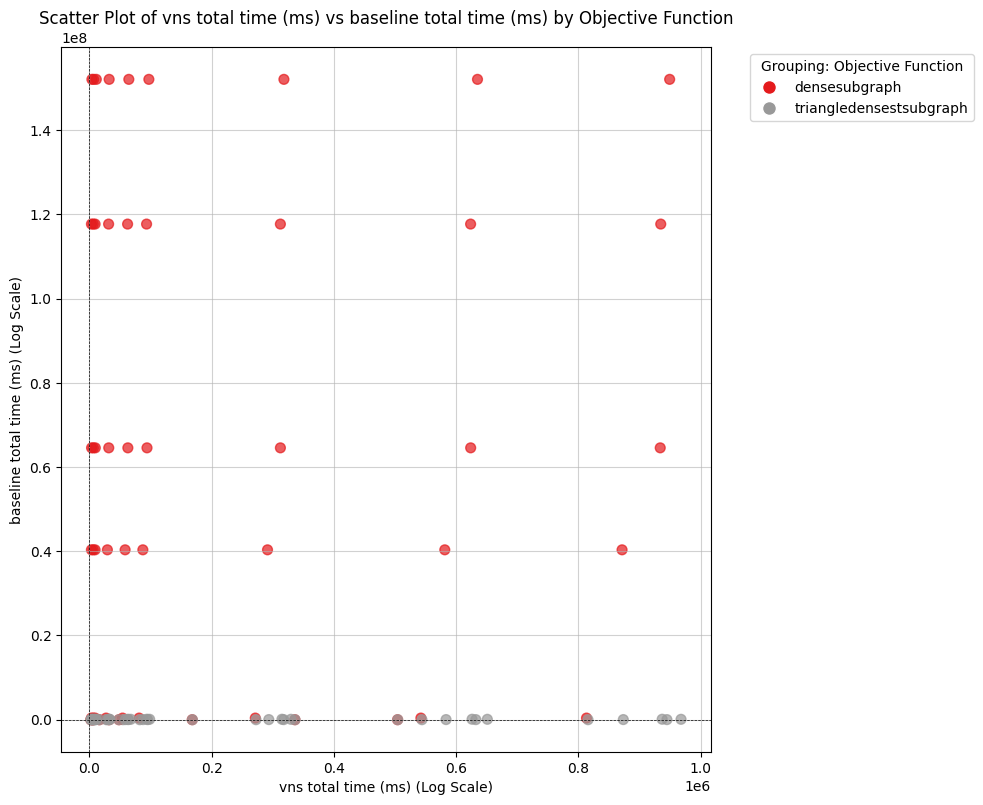

In [37]:
plot_scatter_log_quadrants(df, 'vns total time (ms)', 'baseline total time (ms)', ['Objective Function'])

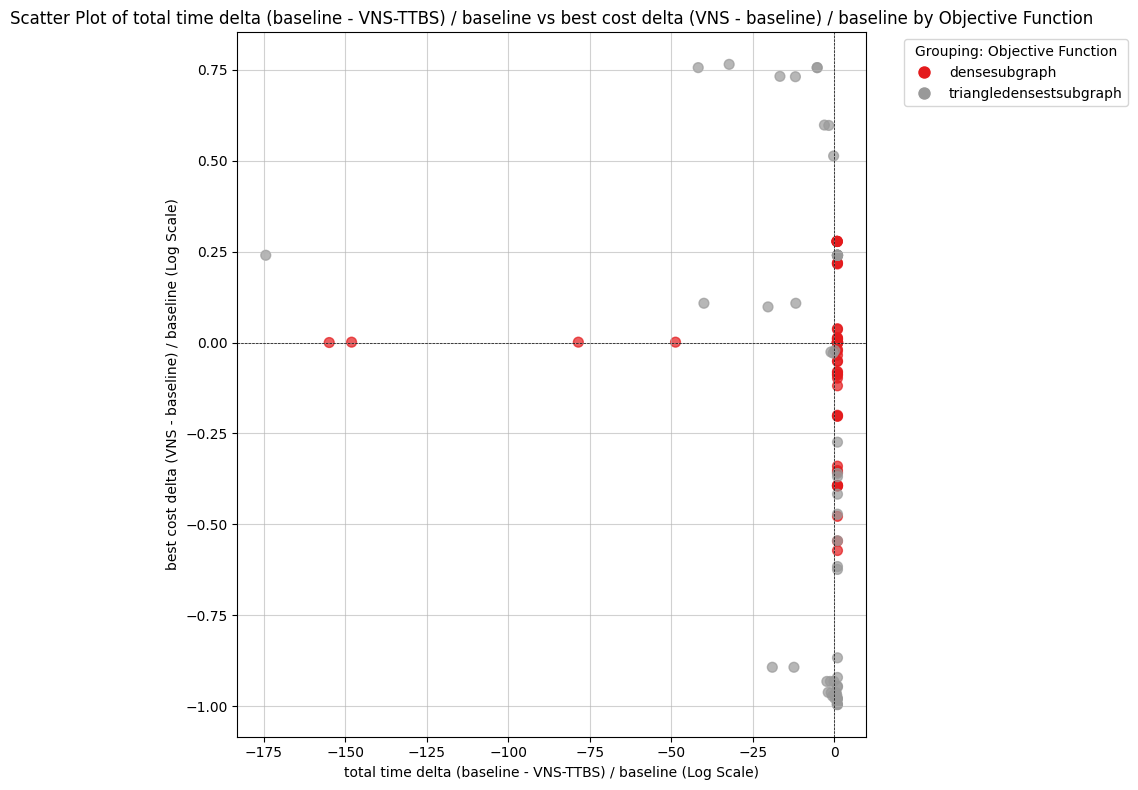

In [46]:
plot_scatter_log_quadrants(df, 'total time delta (baseline - VNS-TTBS) / baseline', 'best cost delta (VNS - baseline) / baseline', ['Objective Function'])